In [2]:
%matplotlib inline

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import math
import matplotlib.dates as mdates

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [4]:
df = pd.read_csv('main_data.csv')
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3043746 entries, 0 to 3043745
Data columns (total 2 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Time (UTC)  str    
 1   prs(m)      float64
dtypes: float64(1), str(1)
memory usage: 46.4 MB


,prs(m)
count,3.029938e+06
mean,1.396747e+00
std,4.506701e-01
min,-9.060000e-01
25%,1.123000e+00
50%,1.340000e+00
75%,1.608000e+00
max,8.152700e+01


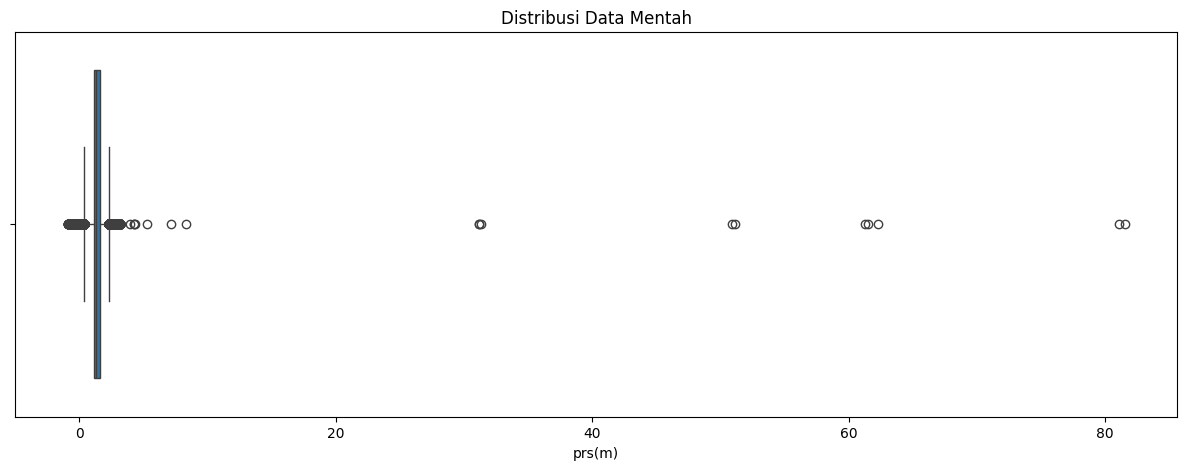

In [5]:
plt.figure(figsize=(15, 5))
sns.boxplot(x=df['prs(m)'])
plt.title('Distribusi Data Mentah')
plt.show()

In [6]:
df['Time (UTC)'] = pd.to_datetime(df['Time (UTC)'])
df.set_index('Time (UTC)', inplace=True)

display(df.head())
display(df.iloc[1500008:1500013])
display(df.tail())

,prs(m)
Time (UTC),
2020-01-01 00:01:00,0.621
2020-01-01 00:02:00,0.536
2020-01-01 00:03:00,0.688
2020-01-01 00:04:00,0.693
2020-01-01 00:05:00,0.633


,prs(m)
Time (UTC),
2023-01-17 20:15:00,1.451
2023-01-17 20:16:00,1.450
2023-01-17 20:17:00,1.456
2023-01-17 20:18:00,1.454
2023-01-17 20:19:00,1.456


,prs(m)
Time (UTC),
2025-12-31 23:56:00,2.014
2025-12-31 23:57:00,1.976
2025-12-31 23:58:00,1.972
2025-12-31 23:59:00,2.079
2026-01-01 00:00:00,1.960


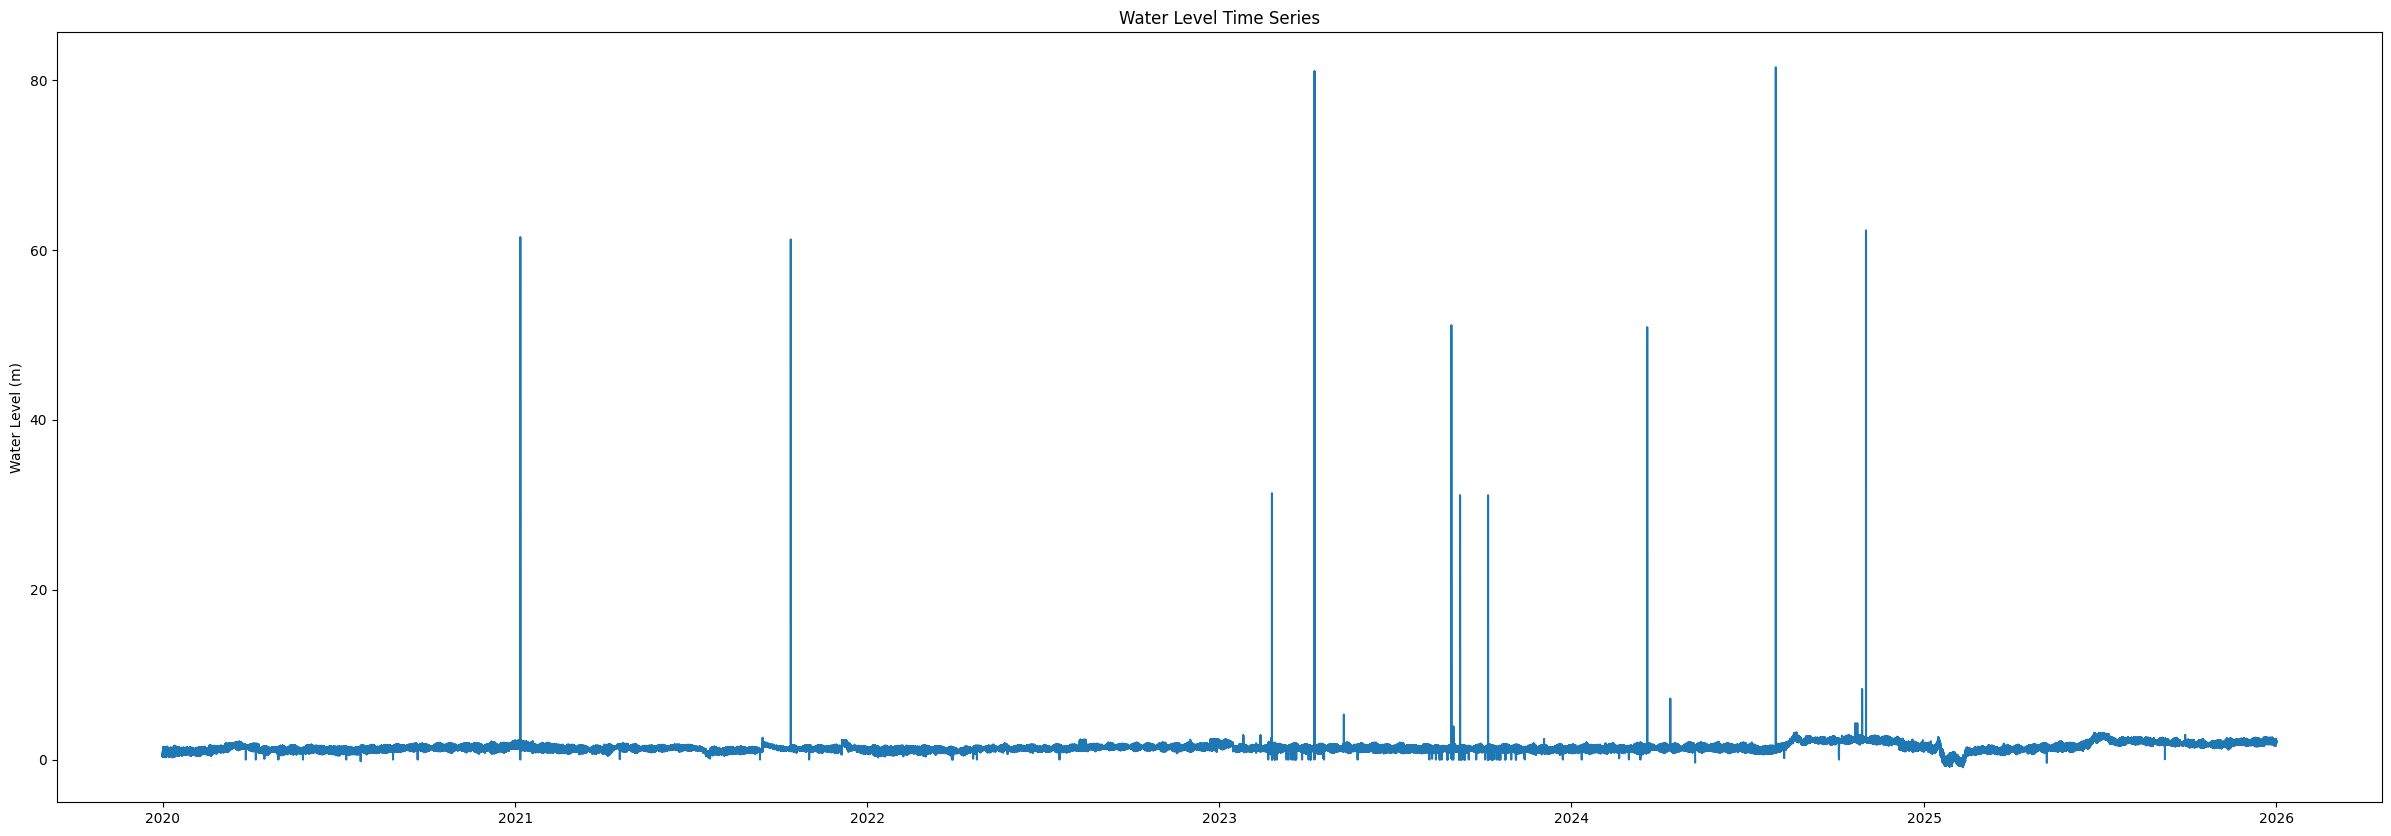

In [7]:
plt.figure(figsize=(30,10))
plt.plot(df['prs(m)'])
plt.title("Water Level Time Series")
plt.ylabel("Water Level (m)")
plt.show()

In [8]:
print("Total entries:", len(df))
print("Missing value:", df['prs(m)'].isna().sum())

Q1 = df['prs(m)'].quantile(0.25)
Q3 = df['prs(m)'].quantile(0.75)
IQR = Q3 - Q1
bb = Q1 - 1.5 * IQR
ba = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas Bawah:", bb)
print("Batas Atas:", ba)

nilai_missing = df['prs(m)'].isna()
nilai_outlier = (df['prs(m)'] < bb) | (df['prs(m)'] > ba)
print("Jumlah outlier:", nilai_outlier.sum())

# Tampilkan juga ringkasan baris missing dan outlier secara langsung
display(df[nilai_missing].head(6))
display(df[nilai_outlier].head(6))

Total entries: 3043746
Missing value: 13808
Q1: 1.123
Q3: 1.608
IQR: 0.4850000000000001
Batas Bawah: 0.39549999999999985
Batas Atas: 2.3355
Jumlah outlier: 140583


,prs(m)
Time (UTC),
2020-01-01 11:17:00,NaN
2020-01-01 11:32:00,NaN
2020-01-01 12:17:00,NaN
2020-01-01 20:48:00,NaN
2020-01-03 06:03:00,NaN
2020-01-03 08:02:00,NaN


,prs(m)
Time (UTC),
2020-01-01 03:06:00,0.310
2020-01-01 03:10:00,0.346
2020-01-01 03:38:00,0.363
2020-01-01 03:40:00,0.395
2020-01-01 03:46:00,0.367
2020-01-01 03:51:00,0.392


Sisa missing: 0
Sisa outlier: 0
Duplikasi index: 0


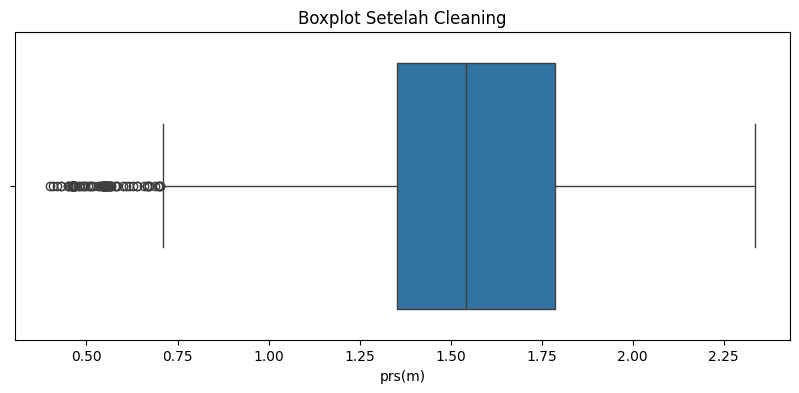

In [9]:
df = df[~df.index.duplicated(keep='first')]

df = df.resample('6h').max()

df.loc[(df['prs(m)'] < bb) | (df['prs(m)'] > ba), 'prs(m)'] = np.nan

df['prs(m)'] = df['prs(m)'].interpolate(method='time')
df['prs(m)'] = df['prs(m)'].bfill().ffill()


print("Sisa missing:", df['prs(m)'].isnull().sum())
print("Sisa outlier:", ((df['prs(m)'] < bb) | (df['prs(m)'] > ba)).sum())
print("Duplikasi index:", df.index.duplicated().sum())

plt.figure(figsize=(10,4))
sns.boxplot(x=df['prs(m)'])
plt.title("Boxplot Setelah Cleaning")
plt.show()

In [10]:
df.to_csv('data6h.csv')

,prs(m)
Time (UTC),
2020-01-01 00:00:00,0.852
2020-01-01 06:00:00,1.095
2020-01-01 12:00:00,1.440
2020-01-01 18:00:00,1.502
2020-01-02 00:00:00,0.854


,prs(m)
Time (UTC),
2022-09-27 00:00:00,1.746
2022-09-27 06:00:00,1.415
2022-09-27 12:00:00,1.412
2022-09-27 18:00:00,1.759
2022-09-28 00:00:00,1.767


,prs(m)
Time (UTC),
2025-12-31 00:00:00,2.05300
2025-12-31 06:00:00,2.02975
2025-12-31 12:00:00,2.00650
2025-12-31 18:00:00,1.98325
2026-01-01 00:00:00,1.96000


C:\Users\faizi\AppData\Local\Temp\ipykernel_6288\3709091863.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


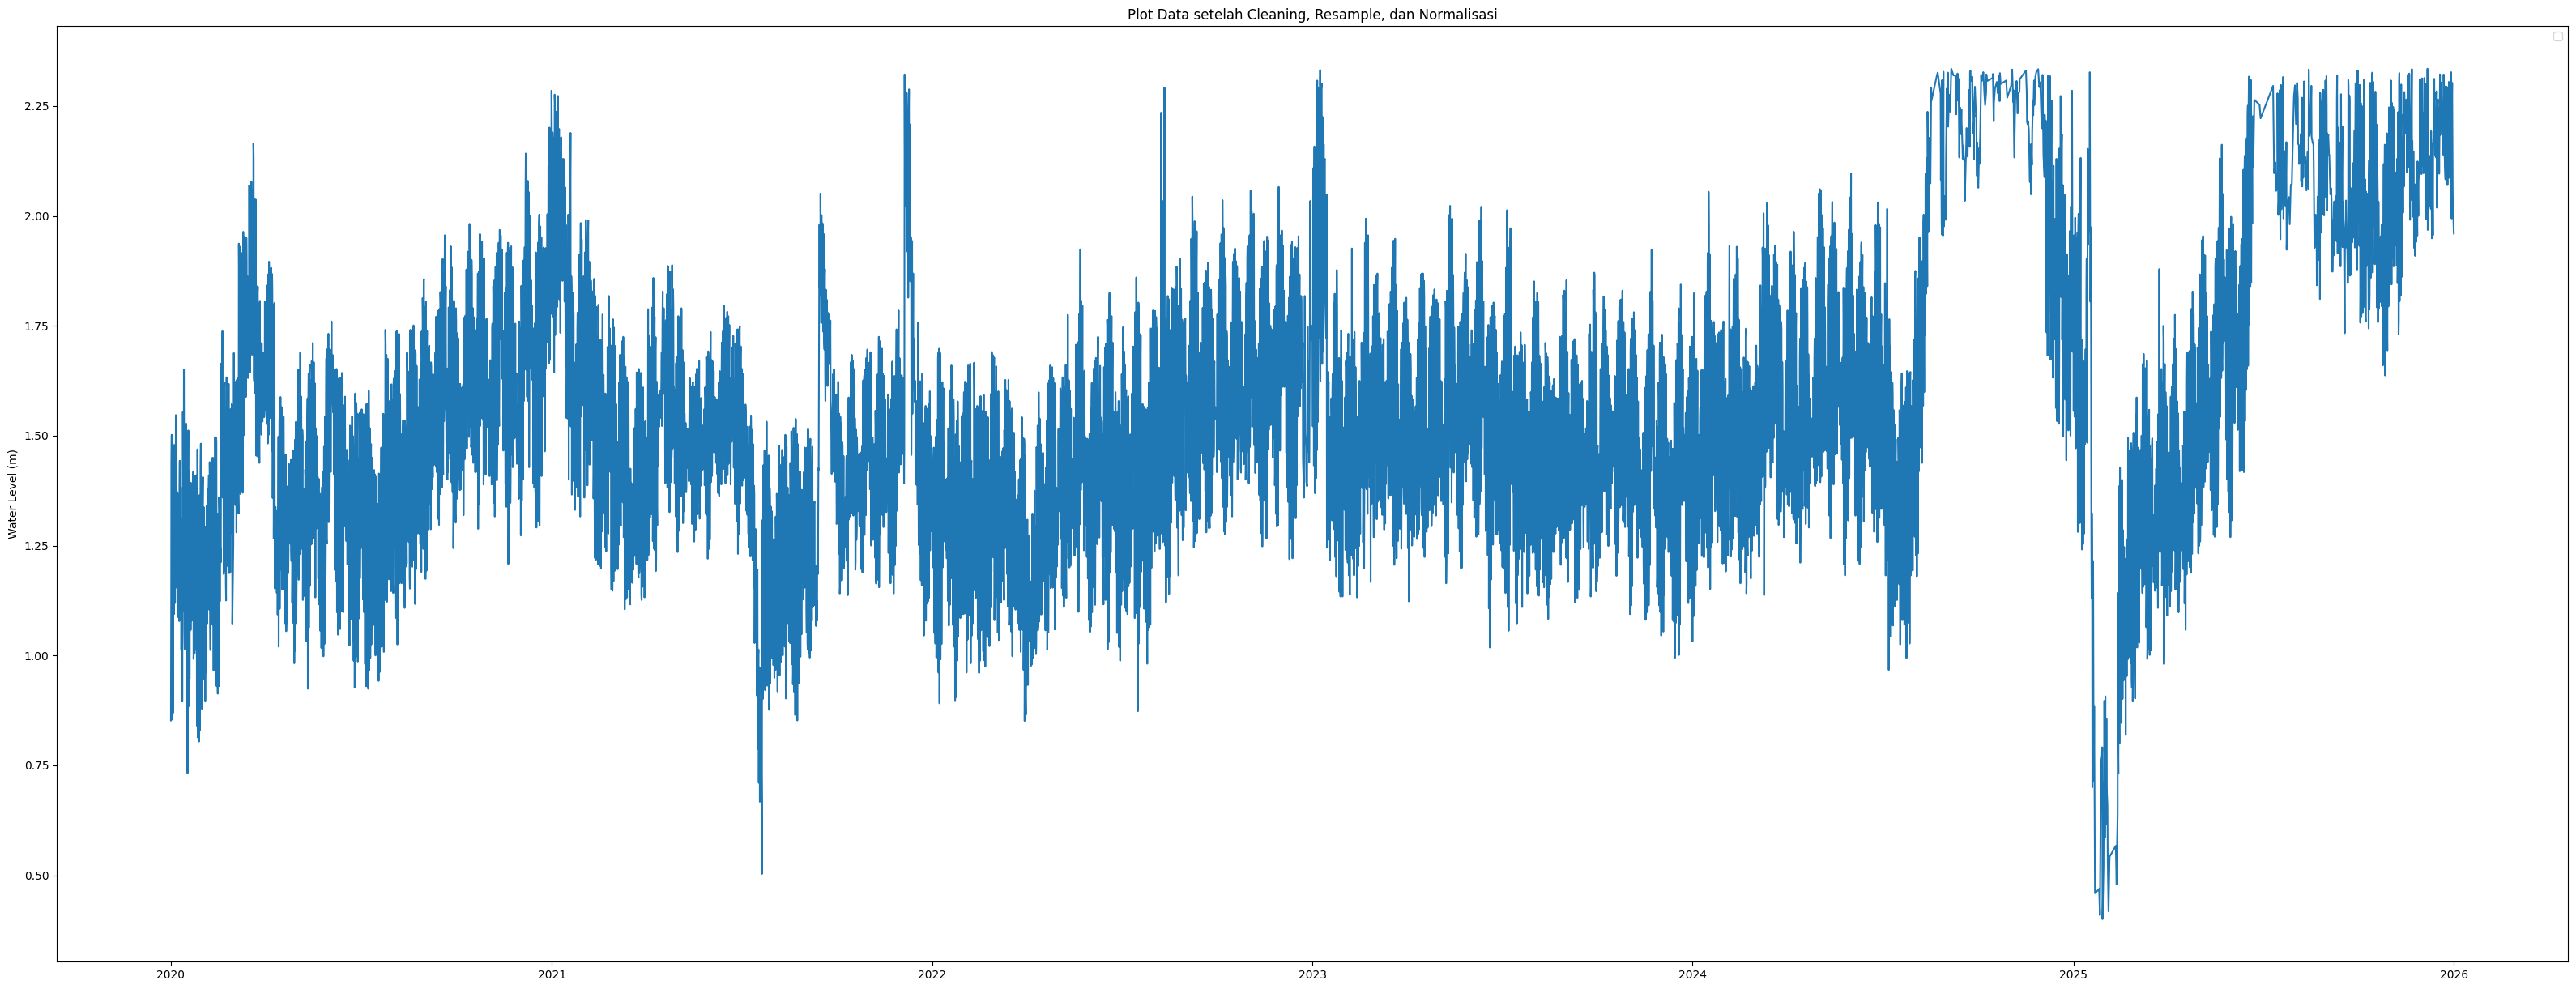

In [11]:
display(df.head()) 
display(df.iloc[4000:4005]) 
display(df.tail())

plt.figure(figsize=(40,15))
plt.plot(df['prs(m)'])
plt.title("Plot Data setelah Cleaning, Resample, dan Normalisasi")
plt.ylabel("Water Level (m)")
plt.legend()
plt.show()

In [12]:
df.describe()

,prs(m)
count,8769.000000
mean,1.584289
std,0.345411
min,0.400000
25%,1.354000
50%,1.543000
75%,1.788000
max,2.335000


Jumlah Data Training  : 7015
Jumlah Data Testing   : 1754
Jumlah Sequence Training  : 6967
Jumlah Sequence Testing   : 1706


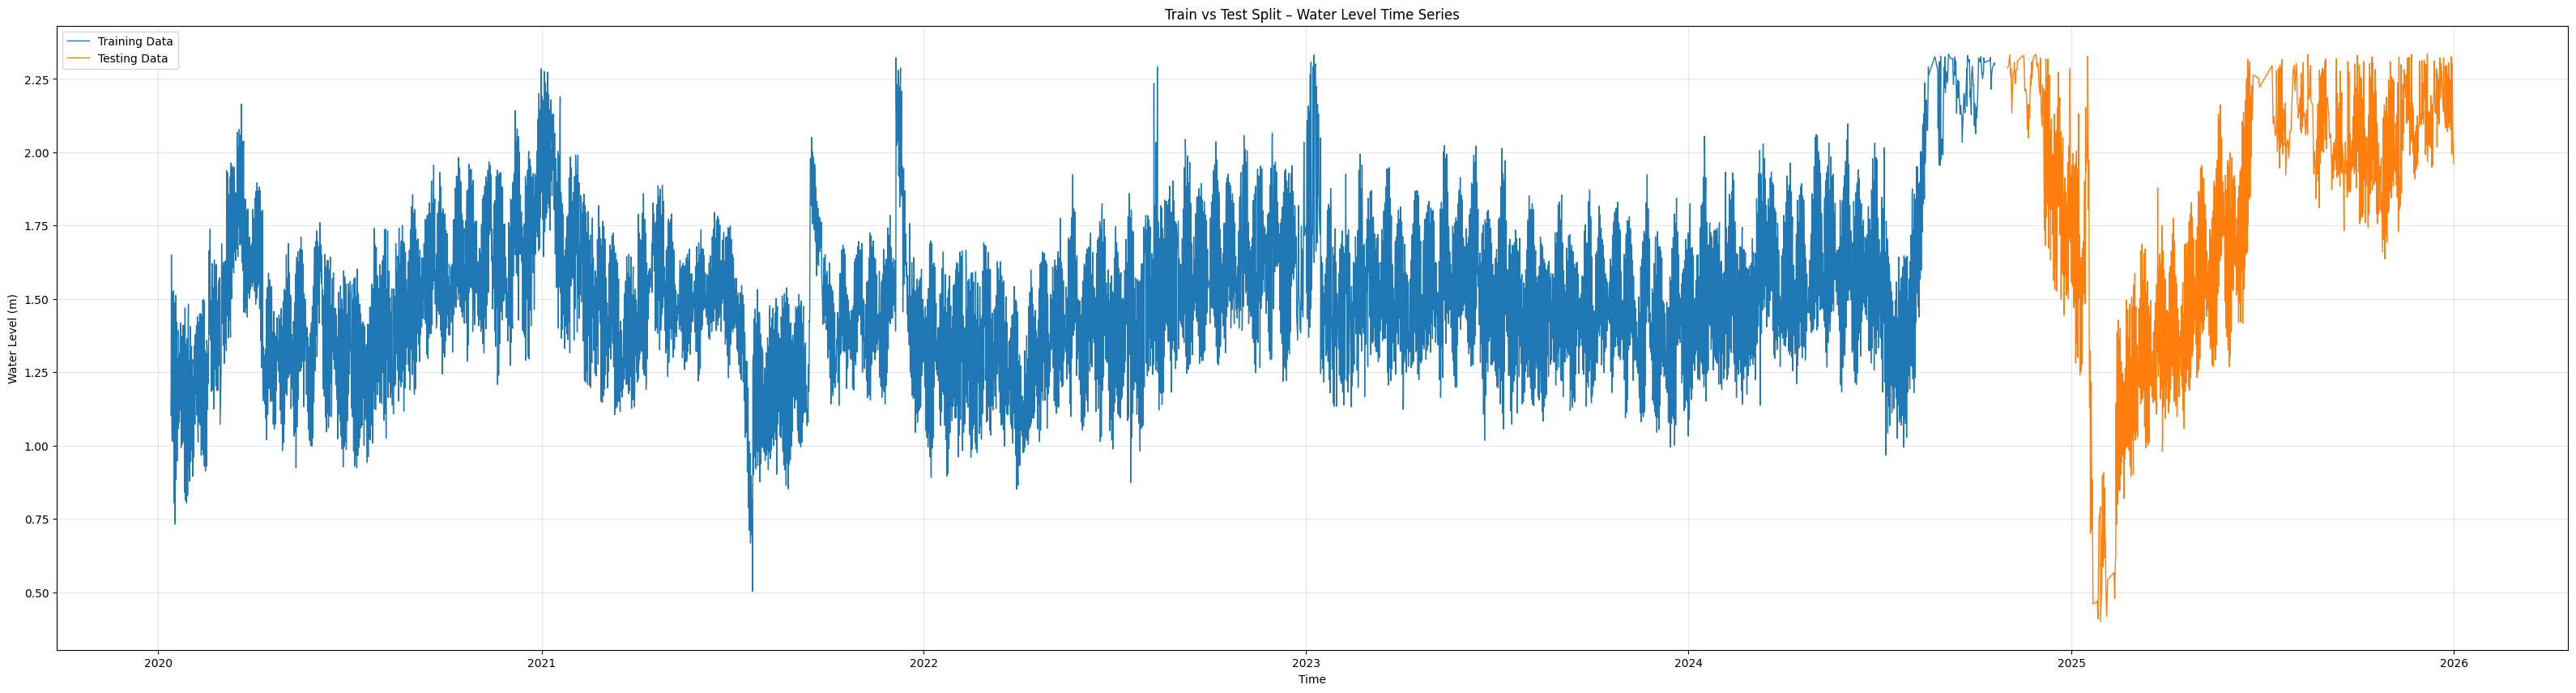

In [13]:
WINDOW_SIZE = 48

data_raw = df[['prs(m)']].values

split_idx = int(0.8 * len(data_raw))
train_data = data_raw[:split_idx]
test_data = data_raw[split_idx:]
print("Jumlah Data Training  :", len(train_data))
print("Jumlah Data Testing   :", len(test_data))

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test  = X_test.reshape(-1, WINDOW_SIZE, 1)

print("Jumlah Sequence Training  :", len(X_train))
print("Jumlah Sequence Testing   :", len(X_test))

time_index = df.index
train_time = time_index[WINDOW_SIZE : split_idx]
test_time  = time_index[split_idx + WINDOW_SIZE :]

y_train_plot = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_plot  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

plt.figure(figsize=(40,10))
plt.plot(train_time, y_train_plot, label="Training Data", linewidth=1)
plt.plot(test_time, y_test_plot, label="Testing Data", linewidth=1)
plt.title("Train vs Test Split – Water Level Time Series")
plt.xlabel("Time")
plt.ylabel("Water Level (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
train_stat = pd.DataFrame({
    'prs(m)': y_train_plot
}).describe()

test_stat = pd.DataFrame({
    'prs(m)': y_test_plot
}).describe()

perbandingan = pd.DataFrame({
    'Train': train_stat['prs(m)'],
    'Test': test_stat['prs(m)']
}).round(3)

print("Perbandingan TRAIN vs TEST")
display(perbandingan)

Perbandingan TRAIN vs TEST


,Train,Test
count,6967.000,1706.000
mean,1.526,1.810
std,0.277,0.466
min,0.503,0.400
25%,1.343,1.538
50%,1.503,1.964
75%,1.681,2.169
max,2.335,2.335


In [15]:
train_df = pd.DataFrame({
    'Time': time_index[:split_idx],
    'Original (prs(m))': train_data.flatten(),
    'Normalized': train_scaled.flatten()
})

print("Data Train:")
display(train_df.head())
display(train_df.tail())

test_df = pd.DataFrame({
    'Time': time_index[split_idx:],
    'Original (prs(m))': test_data.flatten(),
    'Normalized': test_scaled.flatten()
})

print("Data Test:")
display(test_df.head())
display(test_df.tail())

Data Train:


,Time,Original (prs(m)),Normalized
0,2020-01-01 00:00:00,0.852,0.190502
1,2020-01-01 06:00:00,1.095,0.323144
2,2020-01-01 12:00:00,1.440,0.511463
3,2020-01-01 18:00:00,1.502,0.545306
4,2020-01-02 00:00:00,0.854,0.191594


,Time,Original (prs(m)),Normalized
7010,2024-10-18 12:00:00,2.298571,0.980115
7011,2024-10-18 18:00:00,2.300714,0.981285
7012,2024-10-19 00:00:00,2.302857,0.982455
7013,2024-10-19 06:00:00,2.305000,0.983624
7014,2024-10-19 12:00:00,2.298500,0.980076


Data Test:


,Time,Original (prs(m)),Normalized
0,2024-10-19 18:00:00,2.292000,0.976528
1,2024-10-20 00:00:00,2.285500,0.972980
2,2024-10-20 06:00:00,2.279000,0.969432
3,2024-10-20 12:00:00,2.285667,0.973071
4,2024-10-20 18:00:00,2.292333,0.976710


,Time,Original (prs(m)),Normalized
1749,2025-12-31 00:00:00,2.05300,0.846070
1750,2025-12-31 06:00:00,2.02975,0.833379
1751,2025-12-31 12:00:00,2.00650,0.820688
1752,2025-12-31 18:00:00,1.98325,0.807997
1753,2026-01-01 00:00:00,1.96000,0.795306


In [16]:
from datetime import datetime

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=False,
    update_freq='epoch'
)

model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),

    LSTM(128, return_sequences=True),
    Dropout(0.1),

    LSTM(64, return_sequences=False),
    Dropout(0.1),

    Dense(32, activation='tanh'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='mae'
)

model.summary()

callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=10, min_lr=1e-5),
    tensorboard_callback
]

history = model.fit(
    X_train, y_train,
    epochs=200,              
    batch_size=32,          
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - loss: 0.1022 - val_loss: 0.0731 - learning_rate: 5.0000e-04
Epoch 2/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - loss: 0.0899 - val_loss: 0.0699 - learning_rate: 5.0000e-04
Epoch 3/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0891 - val_loss: 0.0835 - learning_rate: 5.0000e-04
Epoch 4/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0887 - val_loss: 0.0904 - learning_rate: 5.0000e-04
Epoch 5/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0871 - val_loss: 0.0679 - learning_rate: 5.0000e-04
Epoch 6/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0841 - val_loss: 0.0898 - learning_rate: 5.0000e-04
Epoch 7/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0761 - val_loss: 0.0988 - learning_rate: 5.0000e-04
Epoch 8/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - loss: 0.0606 - val_loss: 0.0669 - learning_rate: 5.0000e-04
Epoch 9/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0

In [24]:
# 8) prediksi
y_pred_scaled = model.predict(X_test)

# 9) Denormalisasi
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_actual = scaler.inverse_transform(y_pred_scaled).flatten()


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


In [25]:
# 10) Evaluasi
mse  = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)
numerator = np.sum((y_test_actual - y_pred_actual) ** 2)
denominator = np.sum((y_test_actual - np.mean(y_test_actual)) ** 2)
nse = 1 - (numerator / denominator)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.4f} ({mape * 100:.2f}%)")
print(f"R²   : {r2:.4f}")
print(f"NSE  : {nse:.4f}")

MSE  : 0.0083
RMSE : 0.0911
MAE  : 0.0631
MAPE : 0.0432 (4.32%)
R²   : 0.9617
NSE  : 0.9617


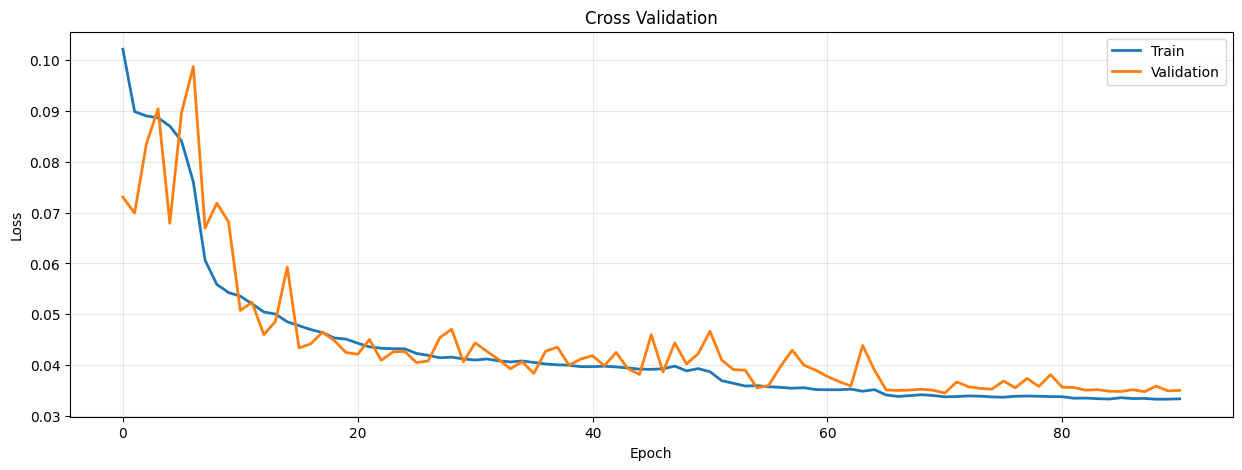

In [26]:
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)

plt.title('Cross Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

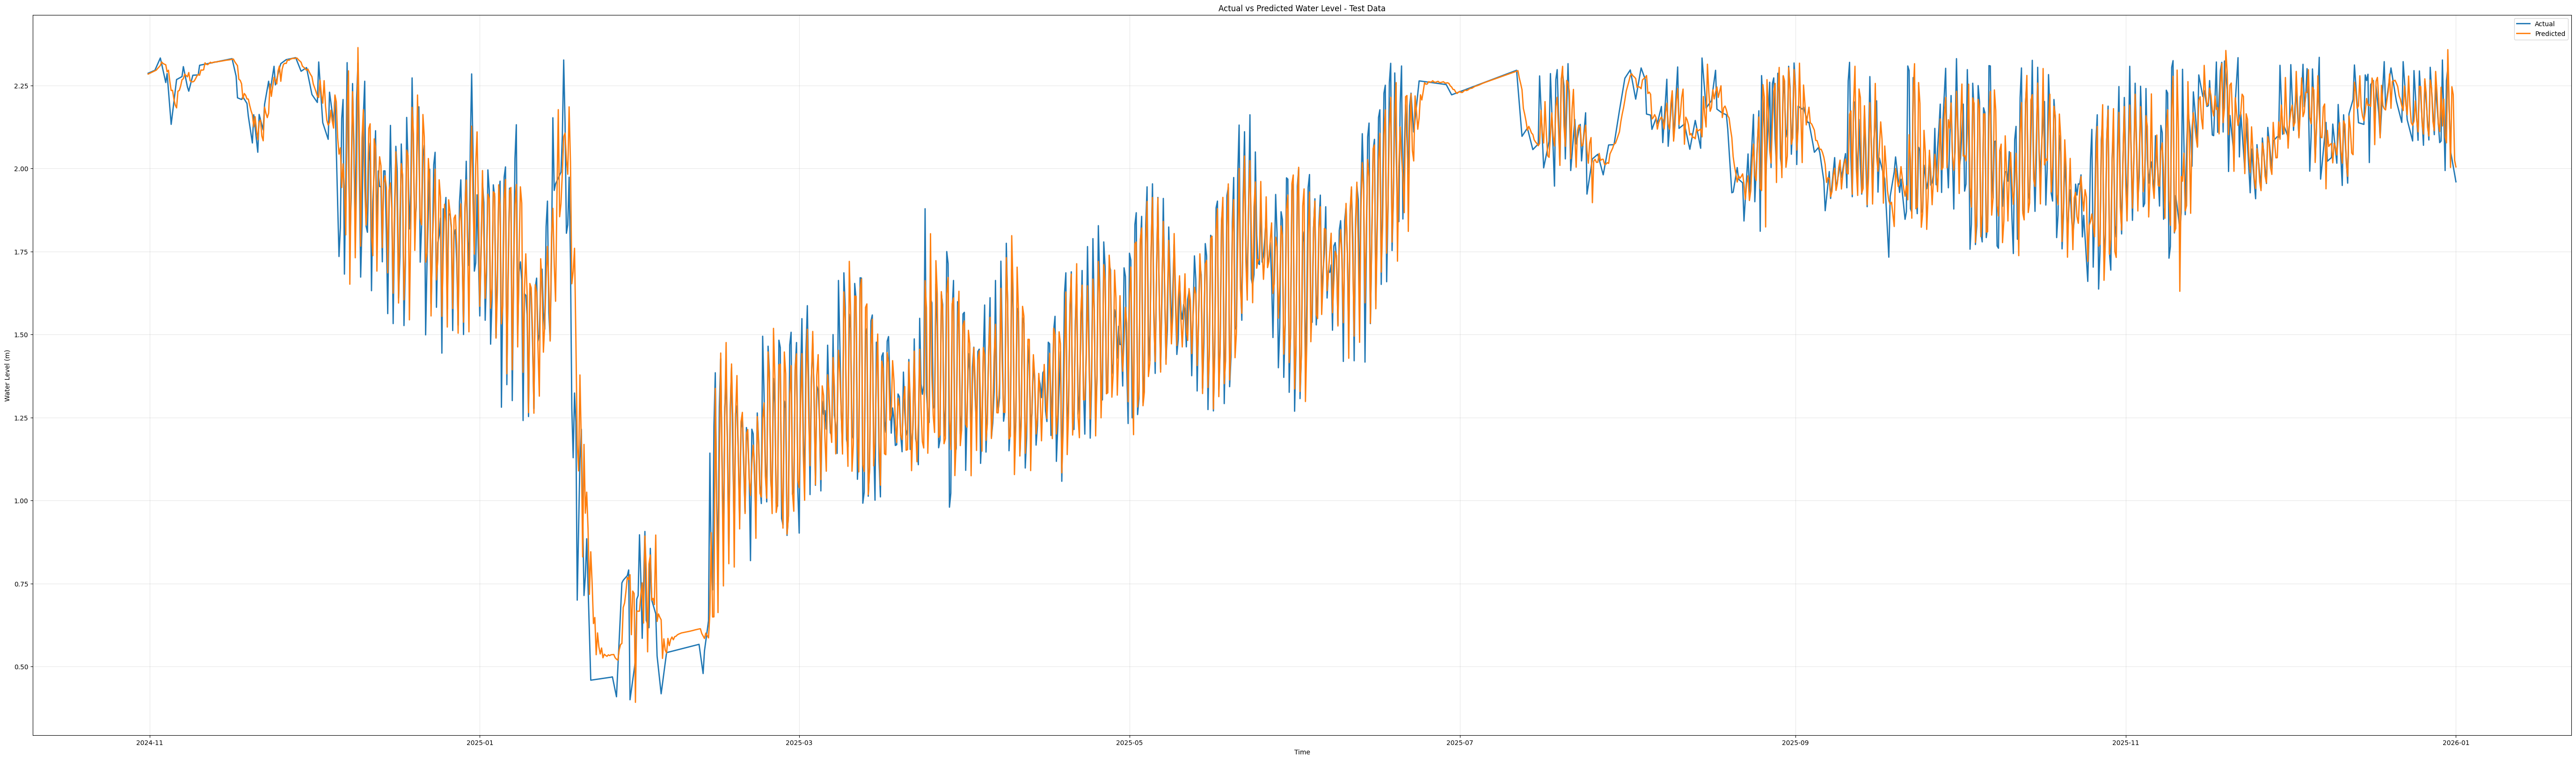

In [27]:
plt.figure(figsize=(70,20))
plt.plot(test_time, y_test_actual, label='Actual', linewidth=2)
plt.plot(test_time, y_pred_actual, label='Predicted', linewidth=2)
plt.title('Actual vs Predicted Water Level - Test Data')
plt.xlabel('Time')
plt.ylabel('Water Level (m)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
# Display predictions in normalized scale + denormalized scale
pred_df = pd.DataFrame({
    'Time': test_time,
    'Actual (Normalized)': y_test.flatten(),
    'Predicted (Normalized)': y_pred_scaled.flatten()
})

pred_df['Actual'] = scaler.inverse_transform(
    pred_df[['Actual (Normalized)']]
)
pred_df['Predicted (Denormalized)'] = scaler.inverse_transform(
    pred_df[['Predicted (Normalized)']]
)

display(pred_df.head())
display(pred_df.tail())

,Time,Actual (Normalized),Predicted (Normalized),Actual,Predicted (Denormalized)
0,2024-10-31 18:00:00,0.973799,0.972450,2.2870,2.284529
1,2024-11-01 00:00:00,0.974782,0.973469,2.2888,2.286396
2,2024-11-01 06:00:00,0.975764,0.974633,2.2906,2.288527
3,2024-11-01 12:00:00,0.976747,0.975681,2.2924,2.290447
4,2024-11-01 18:00:00,0.977729,0.976652,2.2942,2.292226


,Time,Actual (Normalized),Predicted (Normalized),Actual,Predicted (Denormalized)
1701,2025-12-31 00:00:00,0.846070,0.818881,2.05300,2.003190
1702,2025-12-31 06:00:00,0.833379,0.951618,2.02975,2.246364
1703,2025-12-31 12:00:00,0.820688,0.938585,2.00650,2.222488
1704,2025-12-31 18:00:00,0.807997,0.830677,1.98325,2.024800
1705,2026-01-01 00:00:00,0.795306,0.819792,1.96000,2.004858


In [22]:
percentile_95 = np.percentile(df['prs(m)'], 95)
print(f"Persentil ke-95 dari 'prs(m)': {percentile_95}")

Persentil ke-95 dari 'prs(m)': 2.257435


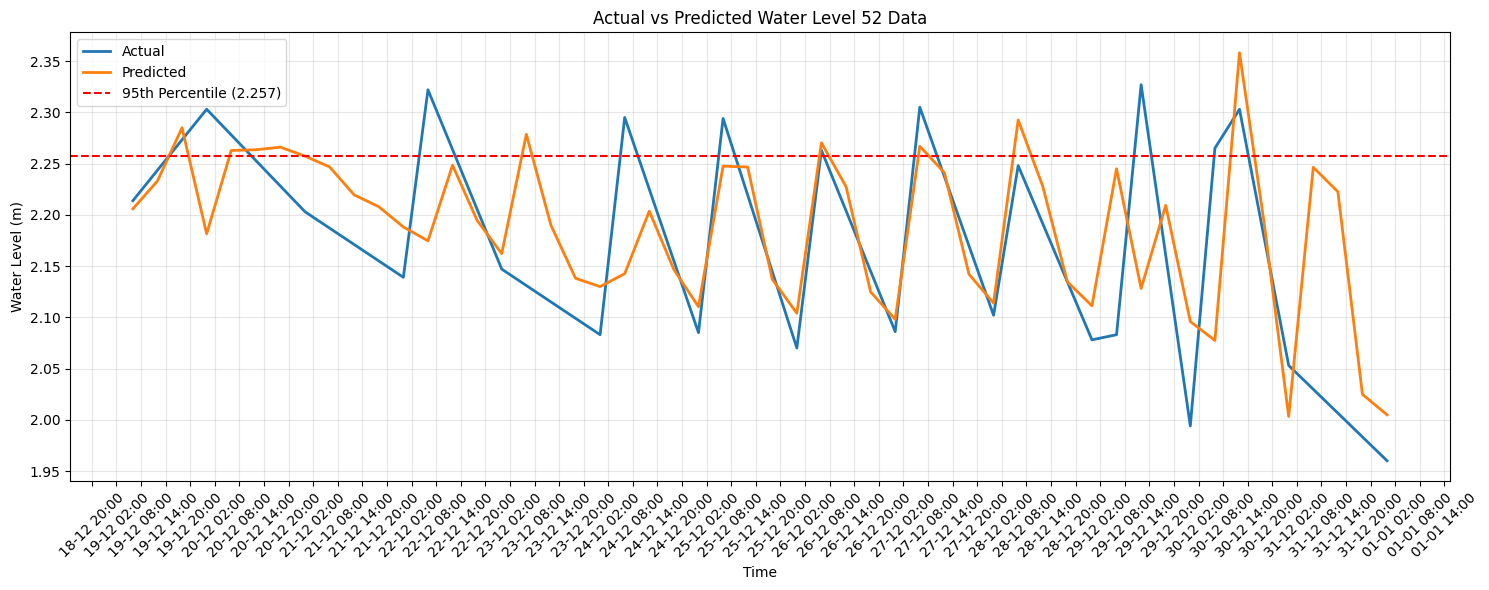

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(test_time[-52:], y_test_actual[-52:], label='Actual', linewidth=2)
plt.plot(test_time[-52:], y_pred_actual[-52:], label='Predicted', linewidth=2)

plt.axhline(y=percentile_95, color='red', linestyle='--',
            label=f'95th Percentile ({percentile_95:.3f})')

plt.title('Actual vs Predicted Water Level 52 Data')
plt.xlabel('Time')
plt.ylabel('Water Level (m)')

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

plt.xticks(rotation=45)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()